In [1]:
## init mongo db and fiftyone connection
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [ ]:
#! jupyter nbconvert presen23-03.ipynb --to html --TagRemovePreprocessor.enabled=True --TagRemovePreprocessor.remove_cell_tags="['hideme']" --TagRemovePreprocessor.remove_input_tags="['hide_code']"

In [2]:
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2
from fiftyone import ViewField as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import random

## renders plotly properly in a html instance. 
#import plotly.io as pio
#pio.renderers.default = "notebook"


In [3]:
## Load dataset and views from mongodb 
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

In [4]:
## get embeddings for each view and normalize it 
nc_emb = nc_view.values("full_embeddings")
wp_emb = wp_view.values("full_embeddings")

## convert to array
nc_emb = np.array(nc_emb)
wp_emb = np.array(wp_emb)

## normalize firsrt
nc_norm = normalize(nc_emb)
wp_norm = normalize(wp_emb)

## CREATE VIEWS OF THE DATASET THAT ARE REPRESENTATIVE OF GEOGRAPHICAL LOCATIONS
## NOTE : Mantasandy is being excluded from further analysis because
## it only has 3 images inside the folder. 
view_GAM = wp_view.match(
    F("subregion")=="GAM"
)
view_FRIWEN = wp_view.match(
    F("subregion")=="FRIWEN"
)
view_MANTASANDY = wp_view.match(
    F("subregion")=="MANTASANDY"
)
view_UM = wp_view.match(
    F("subregion")=="UM"
)
gam_emb = view_GAM.values('full_embeddings')
friwen_emb = view_FRIWEN.values('full_embeddings')
um_emb = view_UM.values('full_embeddings')

norm_gam_emb = normalize(gam_emb)
norm_friwen_emb = normalize(friwen_emb)
norm_um_emb = normalize(um_emb)

print("Number of images per geographical location")
print(f"WP- GAM: {len(view_GAM)}")
print(f"WP - FRIWEN: {len(view_FRIWEN)}")
print(f"WP - MANTASANDY: {len(view_MANTASANDY)}")
print(f"WP -UM: {len(view_UM)}")
print(f"NC: {len(nc_view)}")
print(f"WP (total): {len(wp_view)}")

datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm,
            'WP_GAM':norm_gam_emb,
            'WP_friwen':norm_friwen_emb,
            'WP_mant':norm_um_emb}



Number of images per geographical location
WP- GAM: 512
WP - FRIWEN: 779
WP - MANTASANDY: 3
WP -UM: 745
NC: 716
WP (total): 2039


In [79]:
session = fo.launch_app(dataset,auto=False)

Session launched. Run `session.show()` to open the App in a cell output.


###  Filter field labels

#### Background Complexity

For each object, we have several fields manually created and annotated describing the objects. 

At this section, we are looking if the ID estimation given by MLE has a correlation with manually annotated characteristics, in specific, the background characteristic over the object.

In [19]:
## creates a function
def flatten_nested_embeddings(nested_embeddings):
    """
    Returns a embeddings of shape:
        Total detections, 1024.
    """
    # flatten and avoid null/none values
    final_list = [
        emb for sublist in nested_embeddings 
        if sublist is not None 
        for emb in sublist 
        if emb is not None
    ]
    return np.vstack(final_list)

## compute the ID given by the background diversity:
## construct functions
import time
from contextlib import contextmanager

@contextmanager
def timer(name):
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name}: {end - start:.4f} s")
    
def calculate_MLE(dataset: np.ndarray, 
                  list_neighboors: list = [3,5,10,20],
                  verbose=True):
    """
    Computes Maximum Likelihood Estimation for a set of neighboors,
    Returns:
        dict of MLE distances for each neighboor
    """
    def compute(dataset, 
                n_neighboors: int,
                n_jobs: int = 1):
        """
        Returns a float containing the intrinsic measure. 
        """
        mlea = skdim.id.MLE().fit_transform(X = dataset,
                                                n_neighbors = n_neighboors,
                                                n_jobs = 1)
        return mlea 
        
    results = {}
    for k in list_neighboors:
        if verbose:
            print(f"running {k}")
            with timer(f'k_{k}'):
                mlea = compute(dataset,
                               n_neighboors = k)
                results[k] = mlea
        else:
            mlea = compute(dataset,
                           n_neighboors = k)
            results[k] = mlea
    return results


In [6]:
from fiftyone import ViewField as F

# Filter detections in the 'audit' field
medium_complexity_bg = dataset.filter_labels(
    "audit", 
    F("background_complexity") == "medium"
)

high_complexity_bg = dataset.filter_labels(
    "audit", 
    F("background_complexity") == "high"
)

low_complexity_bg = dataset.filter_labels(
    "audit", 
    F("background_complexity") == "low"
)

# Check how many detections matched
print(high_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(medium_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(low_complexity_bg.count("audit.detections"))

3347
3342
467


Text(0.5, 0.98, 'High complexity background')

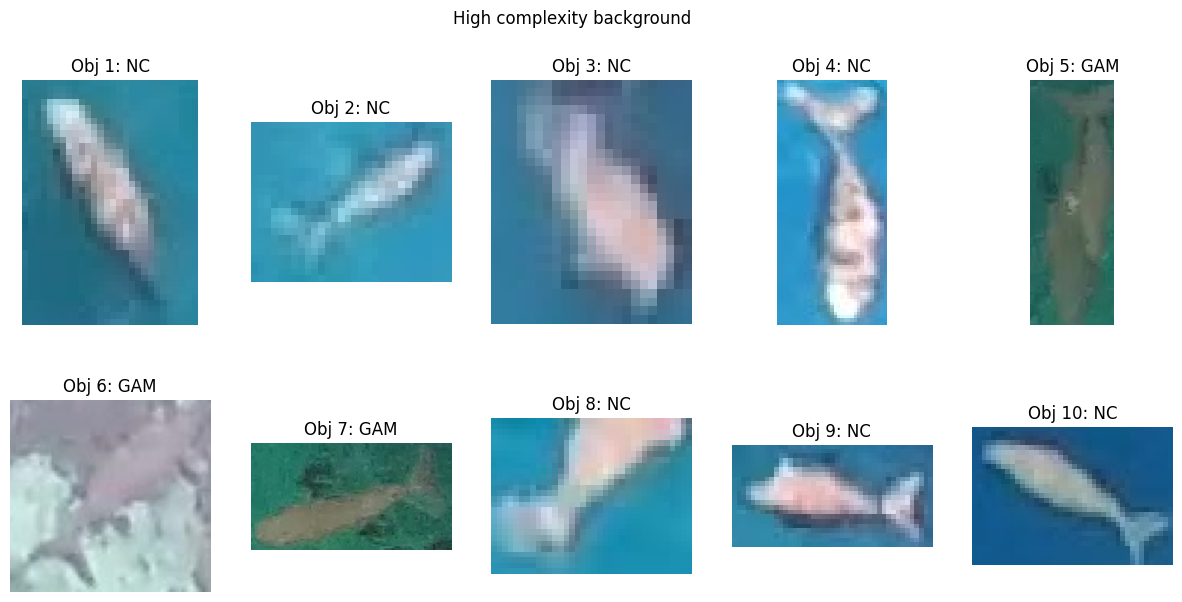

In [50]:
import PIL

patches_view = high_complexity_bg.to_patches("ground_truth")

random_patches = patches_view.shuffle().limit(10)

# 4. Plot using Matplotlib
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, patch in enumerate(random_patches):
    # Load the image
    img = PIL.Image.open(patch.filepath)
    width, height = img.size
    
    # Get bounding box [top_left_x, top_left_y, width, height]
    # Note: These are normalized (0 to 1)
    bbox = patch.ground_truth.bounding_box
    
    # Convert normalized coordinates to pixel coordinates
    left = bbox[0] * width
    top = bbox[1] * height
    right = (bbox[0] + bbox[2]) * width
    bottom = (bbox[1] + bbox[3]) * height
    
    # Crop the image to the object
    obj_crop = img.crop((left, top, right, bottom))
    
    axes[i].imshow(obj_crop)
    axes[i].set_title(f"Obj {i+1}: {patch.ground_truth.subregion}")
    axes[i].axis("off")

fig.suptitle("High complexity background")

Text(0.5, 0.98, 'Medium complexity background')

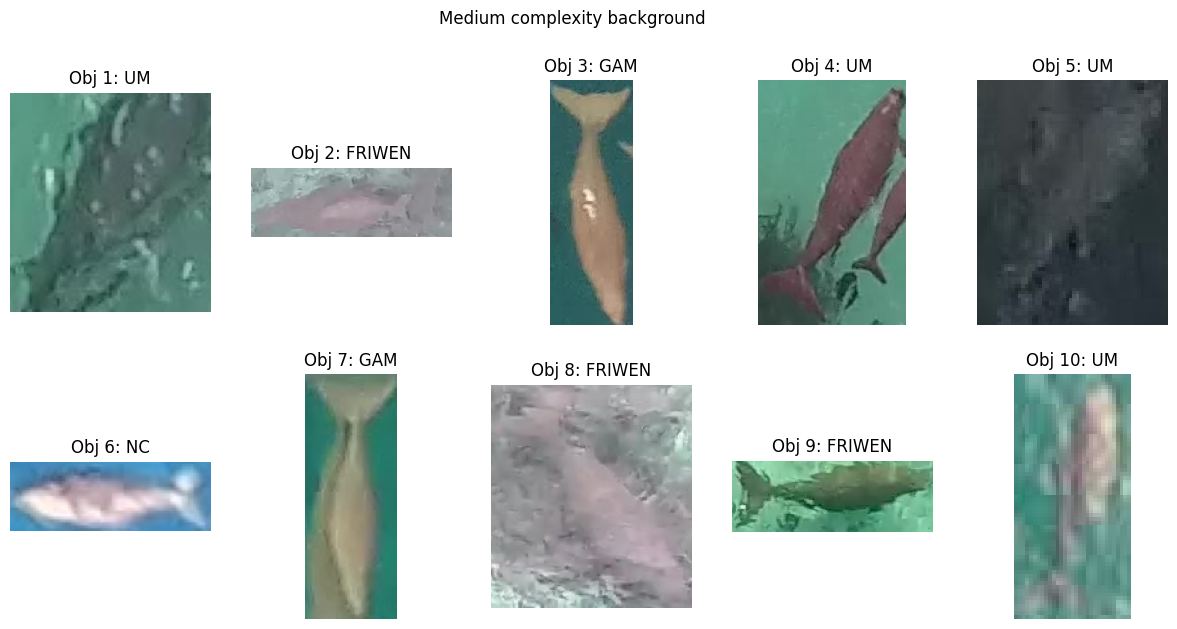

In [46]:

patches_view = medium_complexity_bg.to_patches("ground_truth")

random_patches = patches_view.shuffle().limit(10)

# 4. Plot using Matplotlib
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, patch in enumerate(random_patches):
    # Load the image
    img = PIL.Image.open(patch.filepath)
    width, height = img.size
    
    # Get bounding box [top_left_x, top_left_y, width, height]
    # Note: These are normalized (0 to 1)
    bbox = patch.ground_truth.bounding_box
    
    # Convert normalized coordinates to pixel coordinates
    left = bbox[0] * width
    top = bbox[1] * height
    right = (bbox[0] + bbox[2]) * width
    bottom = (bbox[1] + bbox[3]) * height
    
    # Crop the image to the object
    obj_crop = img.crop((left, top, right, bottom))
    
    axes[i].imshow(obj_crop)
    axes[i].set_title(f"Obj {i+1}: {patch.ground_truth.subregion}")
    axes[i].axis("off")

fig.suptitle("Medium complexity background")

Text(0.5, 0.98, 'Low complexity background')

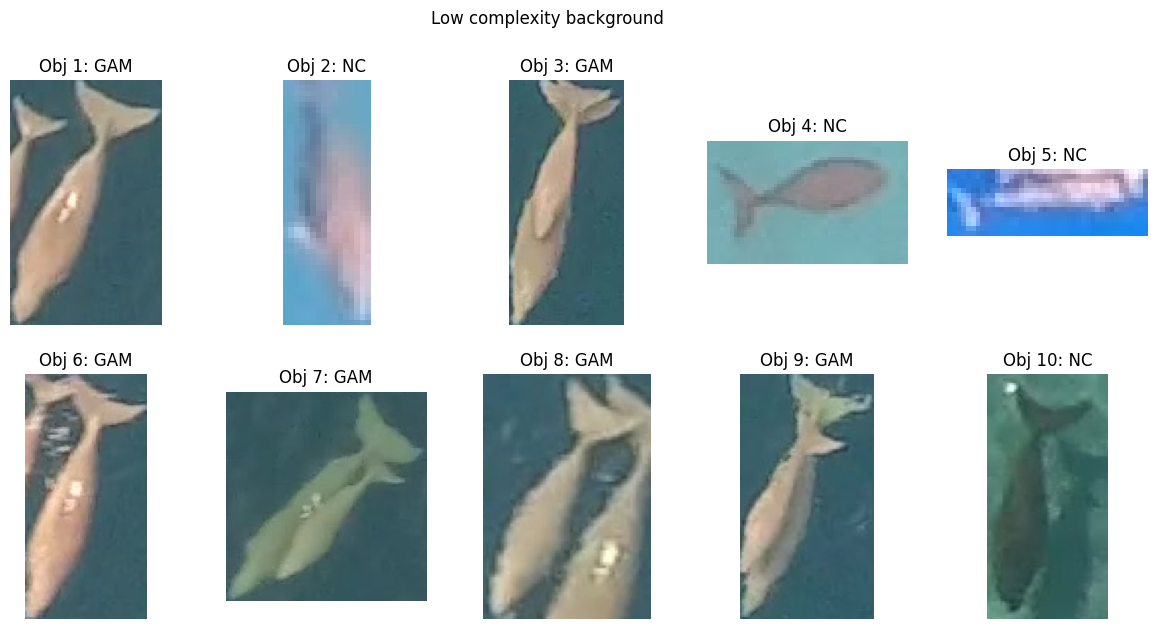

In [47]:
patches_view = low_complexity_bg.to_patches("ground_truth")

random_patches = patches_view.shuffle().limit(10)

# 4. Plot using Matplotlib
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, patch in enumerate(random_patches):
    # Load the image
    img = PIL.Image.open(patch.filepath)
    width, height = img.size
    
    # Get bounding box [top_left_x, top_left_y, width, height]
    # Note: These are normalized (0 to 1)
    bbox = patch.ground_truth.bounding_box
    
    # Convert normalized coordinates to pixel coordinates
    left = bbox[0] * width
    top = bbox[1] * height
    right = (bbox[0] + bbox[2]) * width
    bottom = (bbox[1] + bbox[3]) * height
    
    # Crop the image to the object
    obj_crop = img.crop((left, top, right, bottom))
    
    axes[i].imshow(obj_crop)
    axes[i].set_title(f"Obj {i+1}: {patch.ground_truth.subregion}")
    axes[i].axis("off")

fig.suptitle("Low complexity background")

In [20]:
## retrieve the embeddings for the view
emb_low_bg_complex = flatten_nested_embeddings(
    low_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_medium_bg_complex =  flatten_nested_embeddings(
    medium_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_high_bg_complex =  flatten_nested_embeddings(
    high_complexity_bg.values('ground_truth.detections.patch_embeddings')
)

print("Patch Embeddings size of each dataset:")
print(f"LOW size:{emb_low_bg_complex.shape}")
print(f"MEDIUM: {emb_medium_bg_complex.shape}")
print(f"HIGH: {emb_high_bg_complex.shape}")


Patch Embeddings size of each dataset:
LOW size:(467, 1024)
MEDIUM: (3343, 1024)
HIGH: (3347, 1024)


In [21]:
## compute the MLE for all the datasets
datasets_l ={'LOW': normalize(emb_low_bg_complex), 
             'MEDIUM' : normalize(emb_medium_bg_complex),
             'HIGH': normalize(emb_high_bg_complex)}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[20,30,50],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )


Running:LOW
Running:MEDIUM
Running:HIGH


In [22]:
## plot 
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="ID vs Manually Annotated Complexity background",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

### Evaluating complexity for Target Region

West Papua

In [56]:
from fiftyone import ViewField as F

# Filter detections in the 'audit' field
medium_complexity_bg = wp_view.filter_labels(
    "audit", 
    F("background_complexity") == "medium"
)

high_complexity_bg = wp_view.filter_labels(
    "audit", 
    F("background_complexity") == "high"
)

low_complexity_bg = wp_view.filter_labels(
    "audit", 
    F("background_complexity") == "low"
)

# Check how many detections matched
print(high_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(medium_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(low_complexity_bg.count("audit.detections"))

579
2727
304


In [52]:
wp_view.count('ground_truth.detections')

3615

In [77]:
## retrieve the embeddings for the view
emb_low_bg_complex = flatten_nested_embeddings(
    low_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_medium_bg_complex =  flatten_nested_embeddings(
    medium_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_high_bg_complex =  flatten_nested_embeddings(
    high_complexity_bg.values('ground_truth.detections.patch_embeddings')
)

## filter the medium to match more and less the number of other samples
idx = np.random.choice(emb_medium_bg_complex.shape[0], size=500, replace=False)
emb_medium_bg_complex = emb_medium_bg_complex[idx]


print("Patch Embeddings size of each dataset:")
print(f"LOW size:{emb_low_bg_complex.shape}")
print(f"MEDIUM: {emb_medium_bg_complex.shape}")
print(f"HIGH: {emb_high_bg_complex.shape}")


## compute the MLE for all the datasets
datasets_l ={'LOW': normalize(emb_low_bg_complex), 
             'MEDIUM' : normalize(emb_medium_bg_complex),
             'HIGH': normalize(emb_high_bg_complex)}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[20,30,50],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )


Patch Embeddings size of each dataset:
LOW size:(304, 1024)
MEDIUM: (500, 1024)
HIGH: (570, 1024)
Running:LOW
Running:MEDIUM
Running:HIGH


In [78]:
## plot 
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="West Papua - ID vs Manually Annotated Complexity background",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

In [70]:
wp_view_flpn = wp_view.match(
    F('flight_plan').starts_with('FPLAN'))
wp_view_man = wp_view.match(
    F('flight_plan').starts_with('MAN')
)

# Filter detections in the 'audit' field
medium_complexity_bg = wp_view_man.filter_labels(
    "audit", 
    F("background_complexity") == "medium"
)

high_complexity_bg = wp_view_man.filter_labels(
    "audit", 
    F("background_complexity") == "high"
)

low_complexity_bg = wp_view_man.filter_labels(
    "audit", 
    F("background_complexity") == "low"
)

# Check how many detections matched
print(high_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(medium_complexity_bg.count("audit.detections"))
# Check how many detections matched
print(low_complexity_bg.count("audit.detections"))


## retrieve the embeddings for the view
emb_low_bg_complex = flatten_nested_embeddings(
    low_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_medium_bg_complex =  flatten_nested_embeddings(
    medium_complexity_bg.values('ground_truth.detections.patch_embeddings')
)
emb_high_bg_complex =  flatten_nested_embeddings(
    high_complexity_bg.values('ground_truth.detections.patch_embeddings')
)

print("Patch Embeddings size of each dataset:")
print(f"LOW size:{emb_low_bg_complex.shape}")
print(f"MEDIUM: {emb_medium_bg_complex.shape}")
print(f"HIGH: {emb_high_bg_complex.shape}")


## compute the MLE for all the datasets
datasets_l ={'LOW': normalize(emb_low_bg_complex), 
             'MEDIUM' : normalize(emb_medium_bg_complex),
             'HIGH': normalize(emb_high_bg_complex)}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[20,30,50],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )


570
2684
304
Patch Embeddings size of each dataset:
LOW size:(304, 1024)
MEDIUM: (2685, 1024)
HIGH: (570, 1024)
Running:LOW
Running:MEDIUM
Running:HIGH


In [71]:
## plot 
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="West Papua - ID vs Manually Annotated Complexity background",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

### --------------------

In [ ]:
from pathlib import Path
import random
filepath = dataset.values("filepath")

## iter and extract
extract_first_word = []
for fil in filepath:
    extract_first_word.append(Path(fil).stem.split("_")[0])

len(extract_first_word)

In [70]:
data = random.choices(extract_first_word, k=10)

# def contains_gh(word):
#     return bool(re.search(r"GH", word))

# result = [contains_gh(word) for word in data]
# print(result)



def map_to_gh(word):
    return "GH" if re.search(r"^GH", word) else word

result = list(map(map_to_gh, extract_first_word))
print("Unique labels found it.")
print(pd.Series(result).unique())


Unique labels found it.
<ArrowStringArray>
['GH', 'FPLAN', 'MAN']
Length: 3, dtype: str


In [ ]:
import re 
## add field to dataset

filepath = dataset.values("filepath")

## iter and extract
## very simple extraction of the first sentence 
extract_first_word = []
for fil in filepath:
    extract_first_word.append(Path(fil).stem.split("_")[0])

## we convert everything that is GH as from New Calodonia, and therefore we rename if to GH
def map_to_gh(word):
    return "GH" if re.search(r"^GH", word) else word

result = list(map(map_to_gh, extract_first_word))
print("Unique labels found it.")
print(pd.Series(result).unique())


# create a mapping dictionary: {filepath: tag}
# We use absolute filepaths to be 100% safe
filepaths = dataset.values("filepath")
tag_map = dict(zip(filepaths, result))

# 3. Add the field to the dataset (if it doesn't exist yet)
if not dataset.has_sample_field("flight_plan"):
    dataset.add_sample_field("flight_plan", fo.StringField)

# 4. Bulk update the values
dataset.set_values("flight_plan", tag_map, key_field="filepath")



Unique labels found it.
<ArrowStringArray>
['GH', 'FPLAN', 'MAN']
Length: 3, dtype: str


In [74]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 24, 19, 11, 8, 395000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
     

## Uniqueness

using uniqueness to characterize domain-level diversity, not object-level diversity

In [36]:
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import umap
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE 


The island UM with the flight M5 has a total of 449 images given by a manual flight, that is, following the dugongs manually. 

Here I am evaluating the uniqueness for a given flight plan in order to optimize the labelling process. 

In [22]:
view_UM.count_values("mission_name")
view_UM_M5 = view_UM.match(
    F("mission_name") == "UM_M5"
)

In [23]:
view_UM_M5.count_values("flight_plan")

{'MAN': 449}

In [ ]:
norm_

In [ ]:

def compute_manual_uniqueness(embeddings, k=20):
    # Fit KNN
    knn = NearestNeighbors(n_neighbors=k+1, metric='cosine')
    knn.fit(embeddings)
    
    # Find distances to k+1 neighbors (the first one is the point itself, distance=0)
    distances, _ = knn.kneighbors(embeddings)
    
    # Average the distance to the k actual neighbors
    # Higher average distance = more unique
    uniqueness_scores = distances[:, 1:].mean(axis=1)
    
    # Scale 0 to 1
    uniqueness_scores = (uniqueness_scores - uniqueness_scores.min()) / (uniqueness_scores.max() - uniqueness_scores.min())
    return uniqueness_scores

In [6]:
arr_uniq = compute_manual_uniqueness(norm_um_emb,
                                     k=20)

In [7]:
arr_uniq.shape

(745,)

In [39]:
def plot_uniqueness_landscape(coords_2d_pca,
                              coords_2d_umap, 
                              coords_2d_tsne, 
                            uniqueness_scores,
                            figsize=(12,8),
                            title = "None"
                            ):
    fig, axes = plt.subplots(ncols=3, figsize = figsize)
    axes = axes.flatten()

    # left side is PCA 
    axes[0].scatter(
        coords_2d_pca[:, 0], 
        coords_2d_pca[:, 1], 
        c=uniqueness_scores, 
        cmap='inferno_r', 
        s=15, 
        alpha=0.7
    )
    
    axes[0].set_xlabel("PCA 1")
    axes[0].set_ylabel("PCA 2")
    
    axes[1].scatter(
        coords_2d_umap[:,0],
        coords_2d_umap[:,1],
        c =uniqueness_scores,
        cmap='inferno_r',
        s=15,
        alpha=0.7
    )

    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")

    axes[2].scatter(
        coords_2d_tsne[:,0],
        coords_2d_tsne[:,1],
        c =uniqueness_scores,
        cmap='inferno_r',
        s=15,
        alpha=0.7
    )

    axes[2].set_xlabel("TSNE 1")
    axes[2].set_ylabel("TSNE 2")

    cbar = fig.colorbar(axes[2].collections[0],
                         ax=axes,
                           orientation='vertical',
                            fraction=0.02,
                              pad=0.04)
    #axes[1].set_c
    # Add a colorbar to explain the scale
    cbar.set_label('Uniqueness', rotation=270, labelpad=15)
    
    fig.suptitle(title, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    ##plt.tight_layout()
    plt.show()



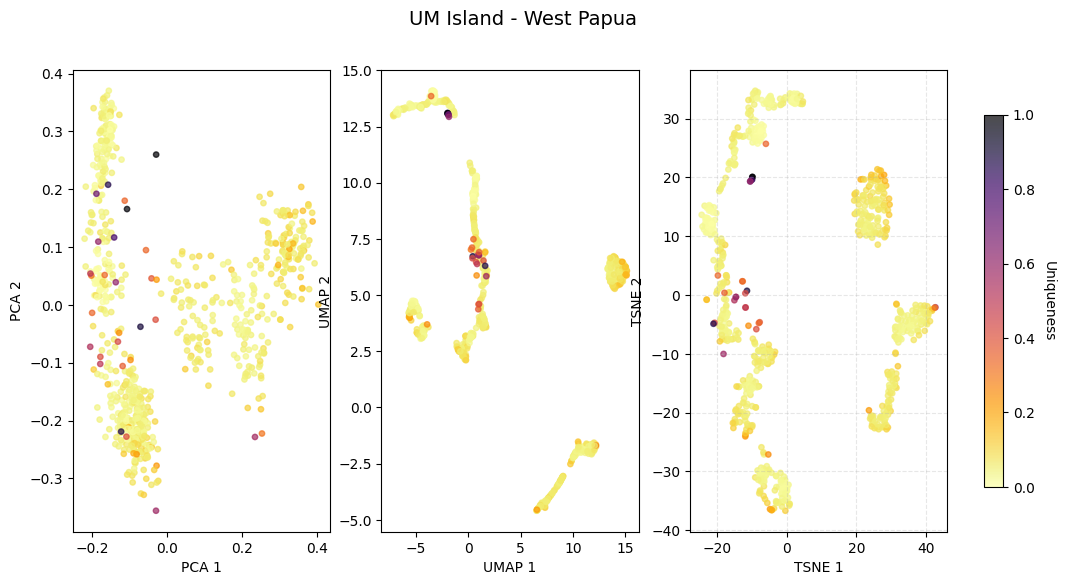

In [40]:

## PLOT uniqueness with PCA reduction
## pca_2d
pca_2d = PCA(n_components=2)
coords_2d_pca = pca_2d.fit_transform(norm_um_emb)

## using UMAP norm_gam_emb
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
coords_2d_umap = reducer.fit_transform(norm_um_emb)  

## calculating tsne
tsne = TSNE(n_components=2, random_state=0, perplexity=30)
coords_2d_tsne = tsne.fit_transform(norm_um_emb)
#  
plot_uniqueness_landscape(coords_2d_pca,
                            coords_2d_umap,
                            coords_2d_tsne,
                            arr_uniq,
                            figsize=(12,6),
                            title="UM Island - West Papua")

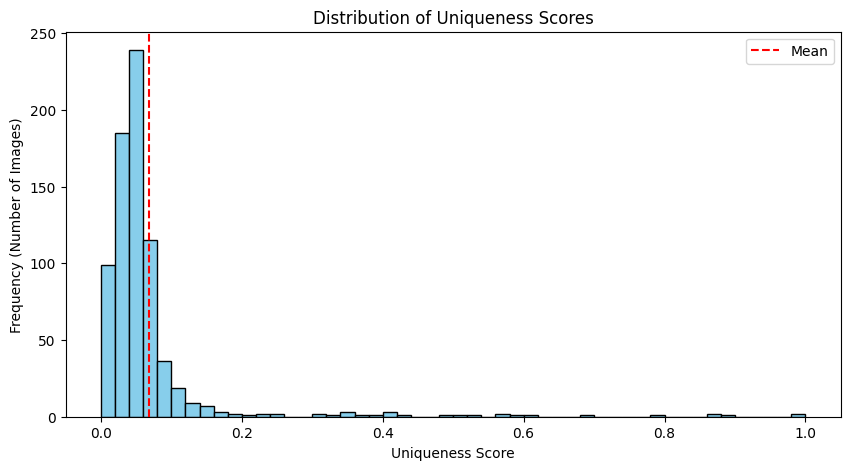

In [10]:
def plot_uniqueness_distribution(uniqueness_scores):
    plt.figure(figsize=(10, 5))
    plt.hist(uniqueness_scores, bins=50, color='skyblue', edgecolor='black')
    plt.axvline(np.mean(uniqueness_scores), color='red', linestyle='dashed', label='Mean')
    
    plt.title("Distribution of Uniqueness Scores")
    plt.xlabel("Uniqueness Score")
    plt.ylabel("Frequency (Number of Images)")
    plt.legend()
    plt.show()

plot_uniqueness_distribution(arr_uniq)

In [19]:

def compute_weighted_uniqueness(embeddings, weights=[0.6, 0.3, 0.1]):
    k = len(weights)
    
    # knn
    # We look for k+1 because the 1st neighbor is always the point itself (dist=0)
    knn = NearestNeighbors(n_neighbors=k + 1,
                            metric='cosine')
    knn.fit(embeddings)
    
    # Extract distances
    # distances shape: (num_samples, k+1)
    distances, _ = knn.kneighbors(embeddings)
    
    # apply the Weights [0.6, 0.3, 0.1]
    # here we slice dists[:, 1:] to ignore the 0-distance to self
    relevant_dists = distances[:, 1:]
    
    # weighted mean
    weighted_dists = np.mean(relevant_dists * weights,
                            axis=1)
    
    # 4. Normalize to [0, 1] for common footing
    # This ensures that '1.0' is always the most unique item in THIS dataset
    if weighted_dists.max() > 0:
        weighted_dists /= weighted_dists.max()
        
    return weighted_dists

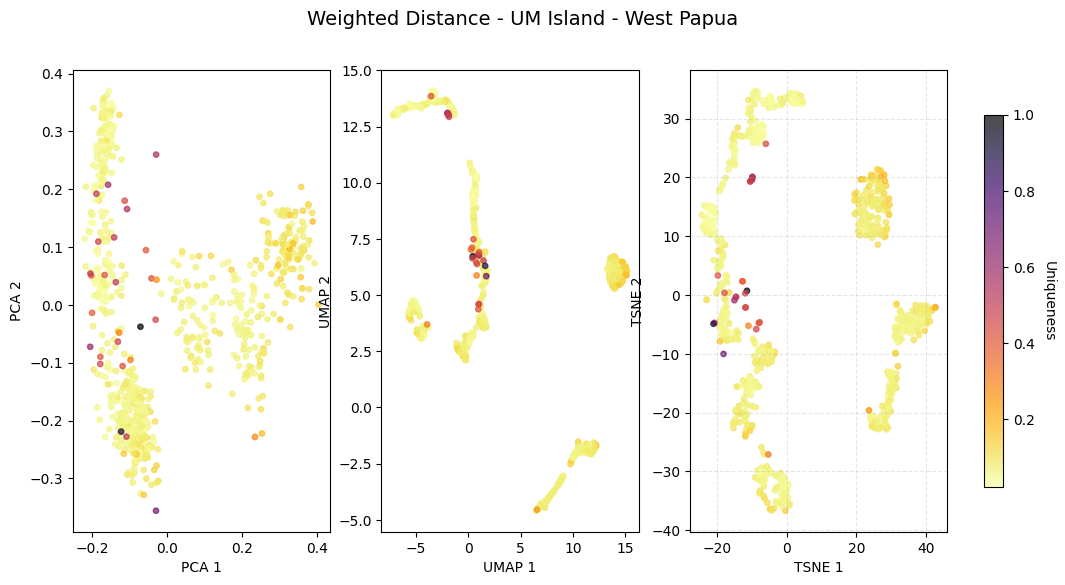

In [43]:
weight_dist = compute_weighted_uniqueness(norm_um_emb,
                                          weights = [0.6, 0.3,0.1])
 
#  
plot_uniqueness_landscape(coords_2d_pca,
                            coords_2d_umap,
                            coords_2d_tsne,
                            weight_dist,
                            figsize=(12,6),
                            title="Weighted Distance - UM Island - West Papua")

When we think about the labels of the objets, since we dont have the objects yet, only the images correspondent to each frame of video, we are using the embeddings of the whole image to provide to the model higher diversity when compared to what the model have seen it from before. 

This diversity suggest global features of images instead of local feature-objects diversity. Such as light, water color and ecological differences of habitat given by corals, presence or absence of algaes. 

Thefore, I suggest:
- Cluster full embeddings for each subplan. (Subplan refers to different flights in the same geographical homogenous region)
- Label 10% of the images for the most representative 




## CORE-SET approach for active-learning 

Sample Selection Pipeline — Summary


Goal: Select ~100 representative images from 745 unlabelled Umandi images to label, instead of labelling everything. Uses DINOv2 global embeddings to capture scene-level properties (water color, lighting, algae).

Approach 1 — K-Medoids + Uniqueness
Stage 1 — Representative samples (K-Medoids):

L2-normalise the raw embeddings
Run K-Medoids (pure numpy/sklearn, no sklearn_extra) with k-medoids++ initialisation
K is fixed in advance (e.g. n_clusters=60)
Returns one real image per cluster — the medoid — which is the most central actual data point in each group

Stage 2 — Diverse samples (Uniqueness):

From the remaining pool, compute weighted 3-NN uniqueness scores
Select the top-N most unique images to cover edge cases and rare conditions


Approach 2 — HDBSCAN + Uniqueness
Stage 1 — Representative samples (HDBSCAN):

L2-normalise the raw embeddings
Reduce dimensionality with UMAP to ~15–30 components (min_dist=0.0) before clustering — this is required because HDBSCAN struggles in high-dimensional spaces (768d) due to the curse of dimensionality
Run HDBSCAN on the reduced embeddings — K is discovered automatically from data density
Select the n_per_cluster most representative points per cluster (highest membership probability)
Noise points (label = -1) are treated as high-uniqueness candidates in Stage 2

Stage 2 — Diverse samples (Uniqueness):

Uniqueness is computed on the original full embeddings (not the reduced ones)
Noise points are prioritised with a score boost before ranking

### KNN 

In [47]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import pairwise_distances


In [65]:
## create manually the medoids since the implementation is scikit-learn-extra has a conflict with C compilers
def kmedoids_plus_plus(embeddings_norm: np.ndarray,
                       n_clusters: int,
                       random_state: int = 42) -> tuple[np.ndarray, np.ndarray]:
    """
    K-Medoids with k-medoids++ initialisation and PAM swap updates.

    Returns
    -------
    medoid_indices : (n_clusters,) indices of selected medoids
    labels         : (N,) cluster assignment per sample
    """
    rng = np.random.default_rng(random_state)
    n   = len(embeddings_norm)

    # ── precompute full pairwise cosine distance matrix ───────────────────
    # shape: (N, N) — feasible for N=745
    D = pairwise_distances(embeddings_norm, metric="cosine")

    # ── k-medoids++ initialisation ────────────────────────────────────────
    # Pick first medoid at random, then each subsequent medoid with
    # probability proportional to its distance from the nearest medoid
    medoids = [rng.integers(0, n)]
    for _ in range(n_clusters - 1):
        # distance from each point to its nearest current medoid
        dist_to_nearest = D[:, medoids].min(axis=1)
        probs = dist_to_nearest ** 2
        probs /= probs.sum()
        medoids.append(rng.choice(n, p=probs))
    medoids = np.array(medoids)

    # ── PAM-style swap iterations ─────────────────────────────────────────
    for iteration in range(100):   # max iterations
        # assign each point to nearest medoid
        labels = D[:, medoids].argmin(axis=1)

        new_medoids = medoids.copy()
        for k in range(n_clusters):
            cluster_mask    = labels == k
            cluster_indices = np.where(cluster_mask)[0]
            if len(cluster_indices) == 0:
                continue
            # pick the point in this cluster that minimises
            # the sum of distances to all other cluster members
            sub_D  = D[np.ix_(cluster_indices, cluster_indices)]
            best   = cluster_indices[sub_D.sum(axis=1).argmin()]
            new_medoids[k] = best

        if np.array_equal(np.sort(new_medoids), np.sort(medoids)):
            print(f"      K-Medoids converged at iteration {iteration + 1}")
            break
        medoids = new_medoids

    labels = D[:, medoids].argmin(axis=1)
    return medoids, labels

In [76]:
def select_unique(embeddings_norm: np.ndarray,
                  already_selected: np.ndarray,
                  n_unique: int,
                  weights: list = None) -> np.ndarray:
    """
    From the pool of images NOT already selected, return the indices of the
    `n_unique` most unique images (highest weighted-kNN uniqueness score).
 
    Parameters
    ----------
    embeddings_norm  : (N, D) full L2-normalised embedding matrix
    already_selected : indices already chosen in Stage 1
    n_unique         : how many unique samples to pick
 
    Returns
    -------
    unique_indices : (n_unique,) global indices into `embeddings_norm`
    """
    all_indices   = np.arange(len(embeddings_norm))
    pool_mask     = np.ones(len(embeddings_norm), dtype=bool)
    pool_mask[already_selected] = False
    pool_indices  = all_indices[pool_mask]
 
    pool_embeddings = embeddings_norm[pool_indices]
    scores          = compute_weighted_uniqueness(pool_embeddings, weights)
 
    top_local       = np.argsort(scores)[::-1][:n_unique]   # descending
    return pool_indices[top_local], scores[top_local]

In [77]:
def build_umap(embeddings_norm: np.ndarray,
               n_components: int = 2) -> np.ndarray:
    reducer = umap.UMAP(
        n_components=n_components,
        metric="cosine",
        random_state=42,
        n_neighbors=15,
        min_dist=0.1,
    )
    return reducer.fit_transform(embeddings_norm)

def plot_selection(umap_2d: np.ndarray,
                   labels: np.ndarray,
                   medoid_indices: np.ndarray,
                   unique_indices: np.ndarray):
    """
    Scatter plot:
      • All points coloured by K-Medoids cluster
      • Medoids marked with a star ★
      • Unique samples marked with a diamond ◆
    """
    n_clusters = labels.max() + 1
    cmap       = plt.get_cmap("tab20", n_clusters)
 
    fig, ax = plt.subplots(figsize=(10, 8))
 
    # — background: all points coloured by cluster
    scatter = ax.scatter(
        umap_2d[:, 0], umap_2d[:, 1],
        c=labels, cmap=cmap,
        s=18, alpha=0.45, linewidths=0,
        zorder=1,
    )
 
    # — Stage 1: medoids (stars)
    ax.scatter(
        umap_2d[medoid_indices, 0], umap_2d[medoid_indices, 1],
        marker="*", s=220, color="white",
        edgecolors="black", linewidths=0.6,
        label=f"Medoids — representative ({len(medoid_indices)})",
        zorder=3,
    )
 
    # — Stage 2: unique samples (diamonds)
    ax.scatter(
        umap_2d[unique_indices, 0], umap_2d[unique_indices, 1],
        marker="D", s=60, color="crimson",
        edgecolors="black", linewidths=0.4,
        label=f"Unique samples — diverse ({len(unique_indices)})",
        zorder=3,
    )
 
    ax.set_title(
        f"K-Medoids + Uniqueness Selection  "
        f"({len(medoid_indices) + len(unique_indices)} / {len(umap_2d)} images)",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(loc="center right", fontsize=9)
    ax.grid(True, alpha=0.2)
 
    plt.tight_layout()
    fig.show()
 

      K-Medoids converged at iteration 5
10 medoids selected
30 unique samples selected
computing UMAP projection …


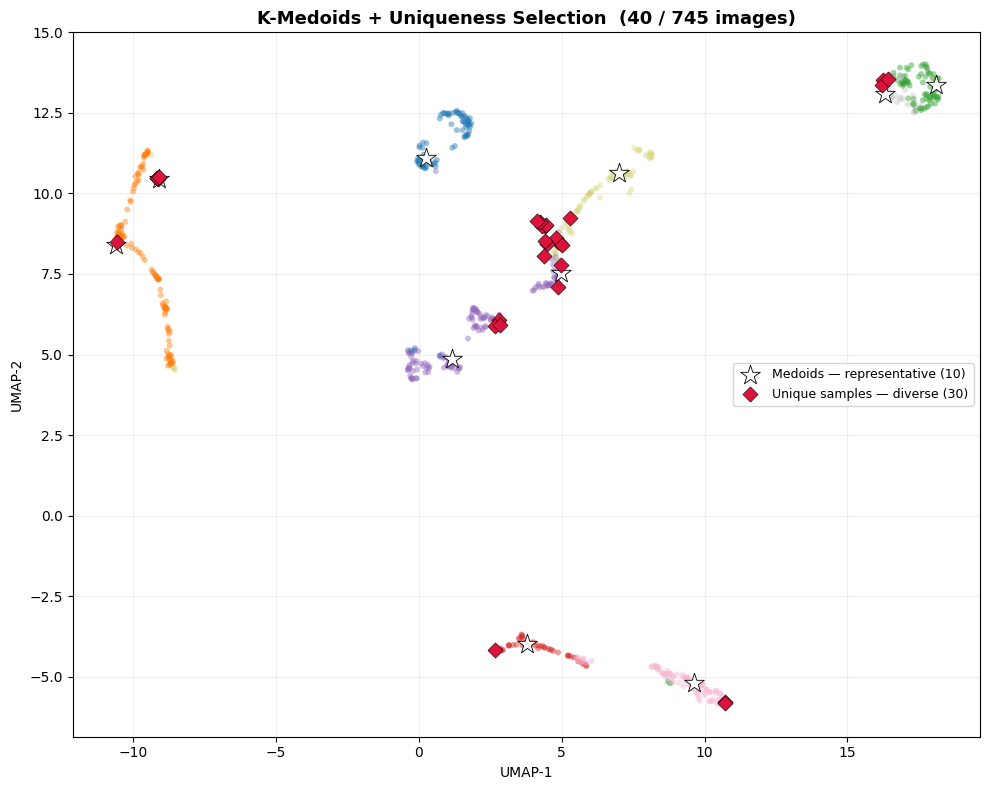

In [79]:
n_clusters = 10 # same number as the number of flight missions. 
n_unique = 30 #number of unique embeddings to select 
uniqueness_weights = [0.6,0.3,0.1]

## fit kmedoids
medoid_indices, cluster_labels = kmedoids_plus_plus(
        norm_um_emb,
        n_clusters=n_clusters,
        random_state=42,
    )
print(f"{len(medoid_indices)} medoids selected")

## compute uniqueness
unique_indices, unique_scores = select_unique(
        norm_um_emb, medoid_indices,
        n_unique,
        uniqueness_weights
    )
print(f"{len(unique_indices)} unique samples selected")

print("computing UMAP projection …")
umap_2d = build_umap(norm_um_emb)
 

plot_selection(umap_2d, cluster_labels, medoid_indices, unique_indices)
 

#### DBSCAN

In [104]:
import hdbscan


def reduce_embeddings(embeddings_norm: np.ndarray,
                      n_components: int = 30,
                      random_state: int = 42) -> np.ndarray:
    """
    Reduce high-dimensional embeddings before clustering.
    n_components=30 preserves structure well while being low enough
    for HDBSCAN to find meaningful density differences.
    """
    reducer = umap.UMAP(
        n_components = n_components,
        metric       = "cosine",
        random_state = random_state,
        n_neighbors  = 15,
        min_dist     = 0.0,    # 0.0 preserves local structure better for clustering
    )
    return reducer.fit_transform(embeddings_norm)

    
def select_hdbscan_representatives(
    embeddings_norm: np.ndarray,
    min_cluster_size: int = 10,
    min_samples: int      = 5,
    n_per_cluster: int    = 1,      
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Cluster with HDBSCAN then select the `n_per_cluster` most representative
    points per cluster (highest membership probability = closest to dense core).

    If a cluster has fewer than n_per_cluster members, all its members
    are selected.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size         = min_cluster_size,
        min_samples              = min_samples,
        metric                   = "euclidean",
        cluster_selection_method = "eom",
        prediction_data          = True,
    )
    clusterer.fit(embeddings_norm)
    labels = clusterer.labels_
    probs  = clusterer.probabilities_

    unique_clusters = sorted(set(labels) - {-1})
    n_clusters      = len(unique_clusters)

    representative_indices = []
    for c in unique_clusters:
        cluster_mask    = labels == c
        cluster_indices = np.where(cluster_mask)[0]
        cluster_probs   = probs[cluster_mask]

        # take top-n by membership probability, capped at cluster size
        n_pick     = min(n_per_cluster, len(cluster_indices))
        top_local  = np.argsort(cluster_probs)[::-1][:n_pick]
        representative_indices.extend(cluster_indices[top_local].tolist())

    print(f"      → HDBSCAN found {n_clusters} clusters, "
          f"{(labels == -1).sum()} noise points")

    return np.array(representative_indices), labels, probs

def select_unique(
    embeddings_norm: np.ndarray,
    already_selected: np.ndarray,
    labels: np.ndarray,
    n_unique: int,
    weights: list = None,
    prioritise_noise: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Select the most unique images from the pool not yet selected.
 
    If `prioritise_noise=True`, HDBSCAN noise points (label == -1) are scored
    first and sorted to the top of the pool before uniqueness ranking, since
    they are by definition the least cluster-like (most isolated) points.
 
    Returns
    -------
    unique_indices : (n_unique,) global indices
    unique_scores  : corresponding uniqueness scores
    """
    all_indices  = np.arange(len(embeddings_norm))
    pool_mask    = np.ones(len(embeddings_norm), dtype=bool)
    pool_mask[already_selected] = False
    pool_indices = all_indices[pool_mask]
 
    pool_embeddings = embeddings_norm[pool_indices]
    scores          = compute_weighted_uniqueness(pool_embeddings, weights)
 
    # Boost noise points: add 1.0 to push them above all non-noise scores
    if prioritise_noise:
        pool_labels = labels[pool_indices]
        noise_boost = (pool_labels == -1).astype(float)
        scores      = scores + noise_boost   # noise points get scores in [1, 2]
 
    top_local    = np.argsort(scores)[::-1][:n_unique]
    return pool_indices[top_local], scores[top_local]

In [111]:
def plot_clusters(umap_2d: np.ndarray,
                  labels: np.ndarray):
    """
    Simple cluster visualisation — no selection overlay.
    Useful to inspect HDBSCAN output before running selection.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    unique_labels = sorted(set(labels) - {-1})
    n_clusters    = len(unique_labels)
    cmap          = plt.get_cmap("tab20", max(n_clusters, 1))

    # noise points
    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(
            umap_2d[noise_mask, 0], umap_2d[noise_mask, 1],
            c="lightgrey", s=14, alpha=0.4, linewidths=0,
            zorder=1, label=f"Noise ({noise_mask.sum()})",
        )

    # one colour per cluster, annotate cluster id at centroid
    for i, c in enumerate(unique_labels):
        mask = labels == c
        ax.scatter(
            umap_2d[mask, 0], umap_2d[mask, 1],
            color=cmap(i), s=18, alpha=0.6, linewidths=0,
            zorder=2, label=f"Cluster {c} ({mask.sum()})",
        )
        # cluster label annotation at median position
        cx, cy = np.median(umap_2d[mask, 0]), np.median(umap_2d[mask, 1])
        ax.text(cx, cy, str(c), fontsize=9, fontweight="bold",
                ha="center", va="center",
                color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc=cmap(i), ec="none", alpha=0.8))

    ax.set_title(
        f"HDBSCAN clusters  |  {n_clusters} clusters  |  "
        f"{noise_mask.sum()} noise points  |  {len(labels)} total images",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(loc="center right", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fig.show()

def plot_selection(umap_2d: np.ndarray,
                   labels: np.ndarray,
                   representative_indices: np.ndarray,
                   unique_indices: np.ndarray,):
    """
    Scatter plot:
      • Clustered points coloured by cluster id
      • Noise points shown in light grey
      • Representatives marked with a star ★
      • Unique/noise samples marked with a diamond ◆
    """
    fig, ax = plt.subplots(figsize=(12, 8))
 
    unique_labels = sorted(set(labels) - {-1})
    n_clusters    = len(unique_labels)
    cmap          = plt.get_cmap("tab20", max(n_clusters, 1))
 
    # — noise points (grey background)
    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(
            umap_2d[noise_mask, 0], umap_2d[noise_mask, 1],
            c="lightgrey", s=14, alpha=0.4, linewidths=0,
            zorder=1, label=f"Noise ({noise_mask.sum()})",
        )
 
    # — clustered points coloured by cluster
    for i, c in enumerate(unique_labels):
        mask = labels == c
        ax.scatter(
            umap_2d[mask, 0], umap_2d[mask, 1],
            color=cmap(i), s=18, alpha=0.45, linewidths=0,
            zorder=2,
        )
 
    # — Stage 1: representatives (stars)
    ax.scatter(
        umap_2d[representative_indices, 0],
        umap_2d[representative_indices, 1],
        marker="*", s=220, color="white",
        edgecolors="black", linewidths=0.6,
        label=f"Representatives ({len(representative_indices)})",
        zorder=4,
    )
 
    # — Stage 2: unique samples (diamonds)
    ax.scatter(
        umap_2d[unique_indices, 0], umap_2d[unique_indices, 1],
        marker="D", s=60, color="crimson",
        edgecolors="black", linewidths=0.4,
        label=f"Unique / noise samples ({len(unique_indices)})",
        zorder=4,
    )
 
    total = len(representative_indices) + len(unique_indices)
    ax.set_title(
        f"HDBSCAN + Uniqueness  "
        f"({total} / {len(umap_2d)} images  |  {n_clusters} clusters found)",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(loc="center right", fontsize=9)
    ax.grid(True, alpha=0.2)
 
    plt.tight_layout()
    fig.show()

Reducing embeddings for clustering (UMAP 30d)...


HDBSCAN | (min_cluster_size=50 | min_samples=10 
      → HDBSCAN found 7 clusters, 46 noise points
 35 representative samples selected
Computing uniqueness on remaining 710 images …
40 unique samples selected
Computing UMAP projection

✓  Total selected: 75 images  (35 representative + 40 unique)


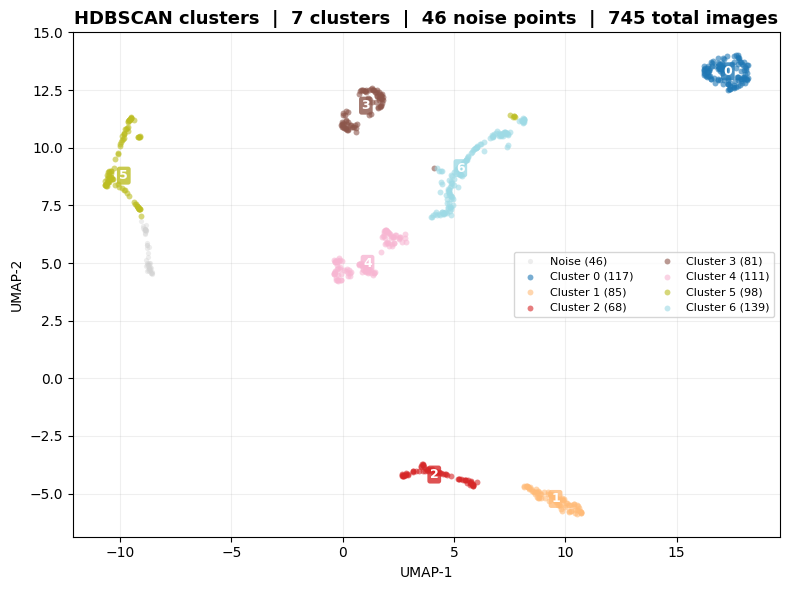

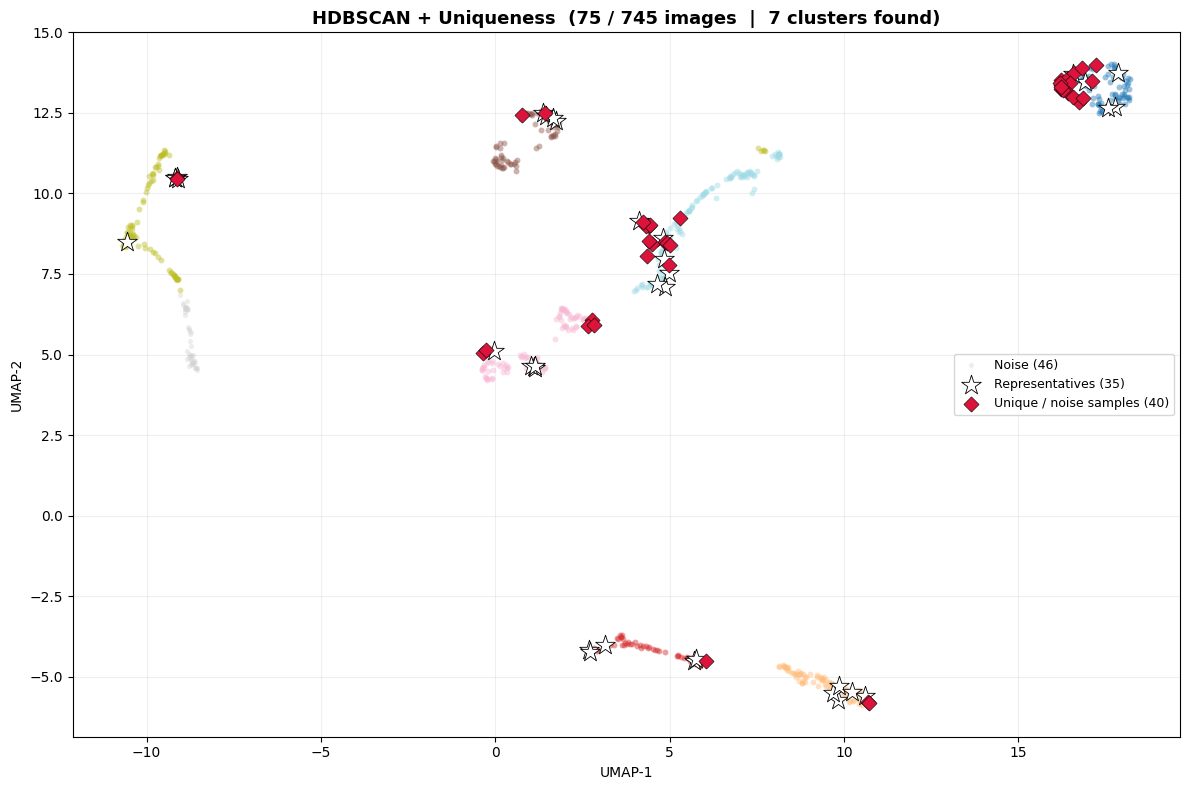

In [116]:
total_budget        = 100    # total images to label
n_unique            = 40     # Stage 2: most-unique from remaining pool
                             # Stage 1 will select one sample per discovered cluster
                             # (number of clusters is data-driven, not fixed)
min_cluster_size    = 50     # minimum points to form a cluster
                             # smaller → more, finer-grained clusters
                             # larger  → fewer, broader clusters
min_samples         = 10      # controls how conservative the clustering is
                             # increase to reduce noise points
 
uniqueness_weights  = [0.6, 0.3, 0.1]   # weights for 3-NN uniqueness
UMAP_N_COMPONENTS   = 2                  # for visualisation only

# Step 1: reduce to 30d for clustering
print("Reducing embeddings for clustering (UMAP 30d)...")
reduced_emb = reduce_embeddings(norm_um_emb, n_components=30)

#  HDBSCAN
print(f"HDBSCAN | (min_cluster_size={min_cluster_size} | min_samples={min_samples} ")

rep_indices, cluster_labels, cluster_probs = select_hdbscan_representatives(
    reduced_emb,
    min_cluster_size,
    min_samples,
    n_per_cluster = 5
)
print(f" {len(rep_indices)} representative samples selected")

# Uniqueness
remaining = len(norm_um_emb) - len(rep_indices)

print(f"Computing uniqueness on remaining {remaining} images …")
unique_indices, unique_scores = select_unique(
    norm_um_emb, rep_indices, cluster_labels,
    n_unique, uniqueness_weights,
    prioritise_noise = False,
)
print(f"{len(unique_indices)} unique samples selected")

#  UMAP 
print("Computing UMAP projection")
umap_2d = build_umap(norm_um_emb)

## plot the clustering by DBSCAN
plot_clusters(umap_2d, cluster_labels)

#plot
plot_selection(umap_2d, cluster_labels, rep_indices, unique_indices)

# ── Output
selected = sorted(set(rep_indices.tolist() + unique_indices.tolist()))
total    = len(selected)
print(f"\n✓  Total selected: {total} images  "
        f"({len(rep_indices)} representative + {len(unique_indices)} unique)")

In [114]:
# Step 1: reduce to 30d for clustering
print("Reducing embeddings for clustering (UMAP 30d)...")
reduced_emb = reduce_embeddings(norm_um_emb, n_components=30)

# Step 2: re-run your parameter search on reduced embeddings
print(f"{'min_cluster_size':>18} {'min_samples':>12} {'n_clusters':>11} {'noise_pts':>10}")
print("-" * 56)
for mcs in [5, 8, 10, 15, 20,30,40,50, 75, 90]:
    for ms in [5,10,15,20, 30]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size         = mcs,
            min_samples              = ms,
            metric                   = "euclidean",
            cluster_selection_method = "eom",
        )
        clusterer.fit(reduced_emb)
        n_clusters = len(set(clusterer.labels_) - {-1})
        n_noise    = (clusterer.labels_ == -1).sum()
        print(f"{mcs:>18} {ms:>12} {n_clusters:>11} {n_noise:>10}")



Reducing embeddings for clustering (UMAP 30d)...


  min_cluster_size  min_samples  n_clusters  noise_pts
--------------------------------------------------------
                 5            5          27         47
                 5           10          17         14
                 5           15          14         47
                 5           20          13         59
                 5           30          10         46
                 8            5          21         33
                 8           10          17         14
                 8           15          12         39
                 8           20          12         41
                 8           30          10         46
                10            5          21         33
                10           10          17         14
                10           15          12         39
                10           20          12         41
                10           30          10         46
                15            5          16         21
        